In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df =pd.read_excel("../data/dataset.xlsx")

In [4]:
print(df.head())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


In [5]:
print(df.shape)

(114000, 21)


In [6]:
print(df.columns)

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113951 non-null  object 
 3   album_name        113988 non-null  object 
 4   track_name        113990 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [8]:
df.isnull().sum()

Unnamed: 0           0
track_id             0
artists             49
album_name          12
track_name          10
popularity           0
duration_ms          0
explicit             0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
track_genre          0
dtype: int64

In [9]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


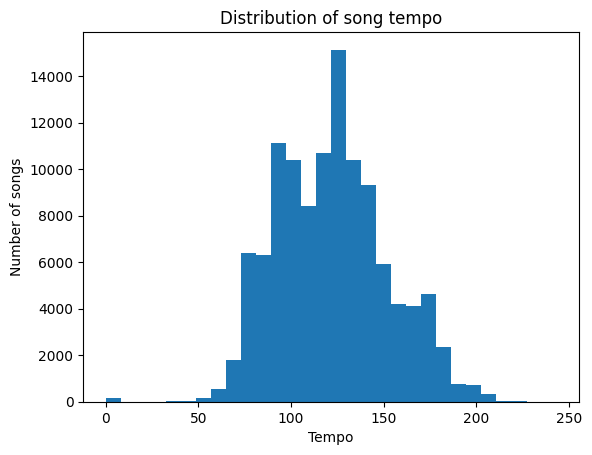

In [10]:
plt.hist(df["tempo"], bins=30)

plt.title("Distribution of song tempo")
plt.xlabel("Tempo")
plt.ylabel("Number of songs")

plt.show()

In [11]:
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [12]:
df = df.dropna()

print(df.shape)

(113940, 21)


In [13]:
print(df.columns.tolist())

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [14]:
def assign_mood(genre):
    genre = str(genre).lower()

    calm_keywords = [
        "acoustic", "ambient", "chill", "classical", "jazz",
        "piano", "sleep", "study", "instrumental", "new-age",
        "opera", "orchestra", "meditation", "relax", "lo-fi",
        "lounge", "soft", "singer-songwriter", "folk"
    ]

    energetic_keywords = [
        "rock", "metal", "punk", "hardcore", "edm", "house",
        "techno", "trance", "dubstep", "drum-and-bass",
        "hip-hop", "rap", "trap", "dance", "electro",
        "electronic", "garage", "grime", "power", "speed"
    ]

    neutral_keywords = [
        "pop", "indie", "alternative", "r&b", "soul",
        "funk", "country", "blues", "latin", "reggae",
        "ska", "disco", "afro", "world", "gospel",
        "k-pop", "j-pop", "britpop", "movie", "soundtrack"
    ]

    for keyword in calm_keywords:
        if keyword in genre:
            return "Calm"

    for keyword in energetic_keywords:
        if keyword in genre:
            return "Energetic"

    for keyword in neutral_keywords:
        if keyword in genre:
            return "Neutral"

    return np.nan

In [15]:
df["mood"] = df["track_genre"].apply(assign_mood)

In [16]:
df = df.dropna(subset=["mood"])

In [17]:
print(df["mood"].value_counts())

mood
Energetic    33988
Neutral      22995
Calm         12000
Name: count, dtype: int64


In [18]:
print(df[["track_genre", "mood"]].sample(20))

           track_genre       mood
88139           reggae    Neutral
38327           garage  Energetic
72434        metalcore  Energetic
107215       synth-pop    Neutral
113495     world-music    Neutral
64572             jazz       Calm
73315   minimal-techno  Energetic
24346   detroit-techno  Energetic
88866           reggae    Neutral
70824         mandopop    Neutral
105169           study       Calm
30992              edm  Energetic
63622           j-rock  Energetic
64832             jazz       Calm
84353       psych-rock  Energetic
81100              pop    Neutral
109122          techno  Energetic
110599          trance  Energetic
15317            chill       Calm
48814         hardcore  Energetic


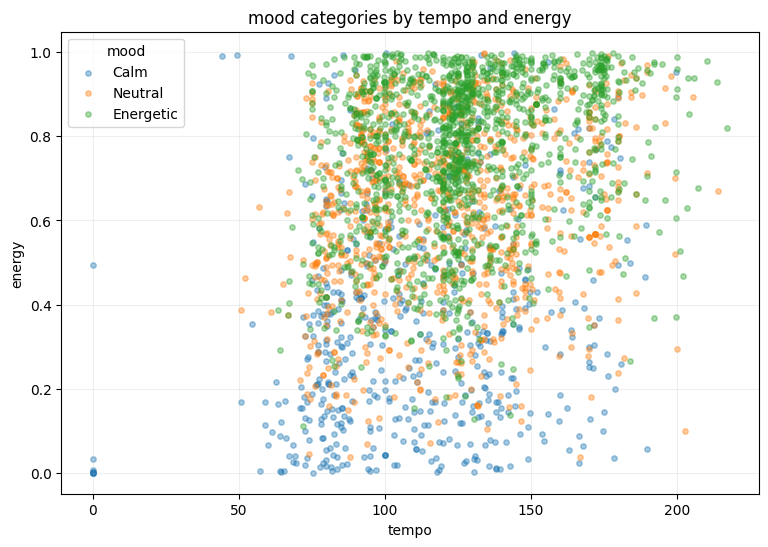

In [205]:
import matplotlib.pyplot as plt

mood_column = "mood"
plot_sample = df.sample(
    n=min(3000, len(df)),
    random_state=42
)
plt.figure(figsize=(9, 6))
for mood in plot_sample[mood_column].dropna().unique():
    mood_data = plot_sample[plot_sample[mood_column] == mood]
    plt.scatter(
        mood_data["tempo"],
        mood_data["energy"],
        label=mood,
        alpha=0.4,
        s=15
    )
plt.xlabel("tempo")
plt.ylabel("energy")
plt.title("mood categories by tempo and energy")
plt.legend(title="mood")
plt.grid(alpha=0.2)
plt.show()

In [19]:
features = ["danceability","energy","acousticness","loudness","tempo","valence"
]

In [20]:
X = df[features]

In [21]:
print(X.head())

   danceability  energy  acousticness  loudness    tempo  valence
0         0.676  0.4610        0.0322    -6.746   87.917    0.715
1         0.420  0.1660        0.9240   -17.235   77.489    0.267
2         0.438  0.3590        0.2100    -9.734   76.332    0.120
3         0.266  0.0596        0.9050   -18.515  181.740    0.143
4         0.618  0.4430        0.4690    -9.681  119.949    0.167


In [22]:
print(X.shape)

(68983, 6)


In [23]:
label_mapping = {"Calm": 0, "Energetic": 1, "Neutral": 2}

In [24]:
y = []

for mood in df["mood"]: y.append(label_mapping[mood])

In [25]:
y = np.array(y)

In [26]:
random_indices = np.random.choice(len(y), size=20, replace=False)

print(y[random_indices])

[2 0 0 1 1 1 2 1 0 2 1 1 1 0 2 1 2 2 2 0]


In [27]:
print(label_mapping)

{'Calm': 0, 'Energetic': 1, 'Neutral': 2}


In [28]:
print(len(y))
print(len(X))

68983
68983


In [29]:
indices = np.arange(len(X))

print(indices[:10])

[0 1 2 3 4 5 6 7 8 9]


In [30]:
np.random.seed(42)

np.random.shuffle(indices)

In [31]:
print(indices[:20])

[62765 41067 24979 40421 32211 40340 54375 14127 48304 56211 12928 68086
 66773  2975 37759 49635 31151 35259 31561 52187]


In [32]:
X = X.iloc[indices]

y = y[indices]

In [33]:
X = X.reset_index(drop=True)

In [34]:
print(X.head())
print(y[:10])

check_df = X.copy()
check_df["label"] = y
print(check_df.head(10))

   danceability  energy  acousticness  loudness    tempo  valence
0         0.155   0.993        0.0911   -16.381  133.085  0.00001
1         0.426   0.487        0.7850    -5.276  135.103  0.28000
2         0.662   0.477        0.7090    -7.218  173.942  0.44900
3         0.705   0.874        0.1700    -2.514  128.020  0.78800
4         0.655   0.716        0.4760    -5.077   80.813  0.52100
[0 2 2 2 2 2 1 1 2 2]
   danceability  energy  acousticness  loudness    tempo  valence  label
0         0.155   0.993      0.091100   -16.381  133.085  0.00001      0
1         0.426   0.487      0.785000    -5.276  135.103  0.28000      2
2         0.662   0.477      0.709000    -7.218  173.942  0.44900      2
3         0.705   0.874      0.170000    -2.514  128.020  0.78800      2
4         0.655   0.716      0.476000    -5.077   80.813  0.52100      2
5         0.548   0.704      0.016800    -4.838  104.666  0.28800      2
6         0.544   0.910      0.001570    -2.461  130.088  0.75600      

In [36]:
split = int(len(X) * 0.8)
print("split index:", split)

split index: 55186


In [38]:
X_train = X.iloc[:split]
X_test = X.iloc[split:]

In [40]:
y_train = y[:split]
y_test = y[split:]

In [44]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (55186, 6)
y_train: (55186,)
X_test: (13797, 6)
y_test: (13797,)


In [45]:
print("training:")
print(np.bincount(y_train))
print("testing:")
print(np.bincount(y_test))

training:
[ 9569 27269 18348]
testing:
[2431 6719 4647]


In [47]:
train_mean = X_train.mean()
print(train_mean)

danceability      0.567369
energy            0.646998
acousticness      0.279723
loudness         -8.161336
tempo           121.729948
valence           0.465559
dtype: float64


In [49]:
train_std = X_train.std()
print(train_std)

danceability     0.177666
energy           0.249867
acousticness     0.323830
loudness         5.223484
tempo           29.926394
valence          0.257071
dtype: float64


In [50]:
X_train = (X_train - train_mean) / train_std

In [51]:
X_test = (X_test - train_mean) / train_std

In [54]:
print(X_train.head())
print(X_train.mean())
print(X_train.std())

   danceability    energy  acousticness  loudness     tempo   valence
0     -2.321031  1.384741     -0.582478 -1.573598  0.379433 -1.810978
1     -0.795698 -0.640333      1.560316  0.552378  0.446865 -0.721822
2      0.532636 -0.680354      1.325625  0.180595  1.744682 -0.064415
3      0.774662  0.908488     -0.338831  1.081143  0.210184  1.254289
4      0.493236  0.276153      0.606111  0.590475 -1.367253  0.215664
danceability    1.457497e-16
energy          8.600778e-17
acousticness    1.108573e-16
loudness       -3.012847e-17
tempo           3.373359e-17
valence         2.157920e-16
dtype: float64
danceability    1.0
energy          1.0
acousticness    1.0
loudness        1.0
tempo           1.0
valence         1.0
dtype: float64


In [56]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

In [161]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate =learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def initialize_weights(self, n_features):
        np.random.seed(42)
        self.weights = np.random.randn(n_features)* 0.01
        self.bias = 0

    def linear_output(self, X):
        return np.dot(X, self.weights)+ self.bias

    def activation(self, z):
        return np.where(z >= 0, 1, 0)
    
    def fit(self, X, y):
        self.initialize_weights(X.shape[1])
        for epoch in range(self.epochs):
            for x_i, target in zip(X, y):
                linear =self.linear_output(x_i)
                prediction = self.activation(linear)
                error =target-prediction
                self.weights += self.learning_rate* error* x_i
                self.bias += self.learning_rate * error

    def predict(self, X):
        linear = self.linear_output(X)
        prediction = self.activation(linear)
        return prediction

    def score(self, X, y):
        predictions =self.predict(X)
        correct = np.sum(predictions == y)
        accuracy = correct/len(y)
        return accuracy


In [162]:
class MultiClassPerceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs =epochs
        self.models = []

    def fit(self, X, y):
        self.models = []
        classes = np.unique(y)
        for current_class in classes:
            binary_labels =np.where(y == current_class, 1, 0)
            model =Perceptron(
                learning_rate=self.learning_rate,
                epochs=self.epochs)
            model.fit(X, binary_labels)
            self.models.append(model)

    def predict(self, X):
            predictions =[]
            for x_i in X:
                outputs =[]
                for model in self.models:
                    linear =model.linear_output(x_i)
                    outputs.append(linear)
                predicted_class= np.argmax(outputs)
                predictions.append(predicted_class)
            return np.array(predictions)
    def score(self, X, y):
        predictions = self.predict(X)
        correct = np.sum(predictions == y)
        accuracy = correct / len(y)
        return accuracy
        
        

In [78]:
perceptron = MultiClassPerceptron(
    learning_rate=0.01,
    epochs=100
)

perceptron.fit(X_train, y_train)

In [79]:
predictions = perceptron.predict(X_test)
print("20 predictions:")
print(predictions[:20])

20 predictions:
[2 2 0 1 1 2 2 2 2 1 2 2 2 1 2 1 2 1 2 2]


In [163]:
accuracy = perceptron.score(X_test, y_test)
print(f"acuracy: {accuracy:.4f}")

acuracy: 0.4896


In [84]:
for i in range(15):
    print(
        f"song {i+1}: actual= {y_test[i]}, predicted = {predictions[i]}"
    )

song 1: actual= 1, predicted = 2
song 2: actual= 2, predicted = 2
song 3: actual= 0, predicted = 0
song 4: actual= 2, predicted = 1
song 5: actual= 1, predicted = 1
song 6: actual= 2, predicted = 2
song 7: actual= 0, predicted = 2
song 8: actual= 2, predicted = 2
song 9: actual= 2, predicted = 2
song 10: actual= 1, predicted = 1
song 11: actual= 2, predicted = 2
song 12: actual= 1, predicted = 2
song 13: actual= 2, predicted = 2
song 14: actual= 0, predicted = 1
song 15: actual= 1, predicted = 2


In [94]:
def confusion_matrix(y_true, y_pred, n_classes):
    matrix = np.zeros((n_classes, n_classes), dtype=int)

    for actual, predicted in zip(y_true, y_pred):
        matrix[actual][predicted] += 1
    return matrix
cm = confusion_matrix(
    y_test,
    predictions,
    n_classes=3)

print(cm)

[[ 259 1404  768]
 [  34 4083 2602]
 [  18 2216 2413]]


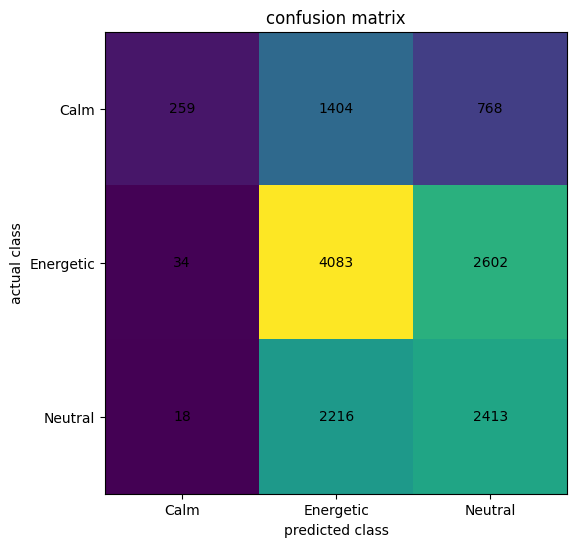

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("confusion matrix")
plt.xlabel("predicted class")
plt.ylabel("actual class")
plt.xticks([0,1,2], ["Calm","Energetic","Neutral"])
plt.yticks([0,1,2], ["Calm","Energetic","Neutral"])

for i in range(3):

    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center")
        
plt.savefig("../results/perceptron_confusion_matrix.png", dpi=300)
plt.show()
        


In [164]:
def precision(cm):
    precisions =[]
    for i in range(len(cm)):
        tp = cm[i][i]
        fp = np.sum(cm[:, i]) - tp
        if tp + fp == 0:
            precisions.append(0)
        else:
            precisions.append(tp / (tp + fp))
    return precisions

In [165]:
def recall(cm):
    recalls =[]
    for i in range(len(cm)):
        tp =cm[i][i]
        fn = np.sum(cm[i, :]) - tp
        if tp+ fn == 0:
            recalls.append(0)
        else:
            recalls.append(tp / (tp + fn))
    return recalls

In [166]:
def f1_score(precision_values, recall_values):
    scores = []
    for p, r in zip(precision_values, recall_values):
        if p + r == 0:
            scores.append(0)
        else:
            scores.append(
                2* p* r /(p + r))
    return scores

In [167]:
precision_values = precision(cm)
recall_values = recall(cm)
f1_values = f1_score(
    precision_values,
    recall_values
)

In [168]:
class_names = [
    "Calm",
    "Energetic",
    "Neutral"]

for i in range(3):
    print(f"\n{class_names[i]}")
    print(f"precision: {precision_values[i]:.3f}")
    print(f"recall: {recall_values[i]:.3f}")
    print(f"f1 score: {f1_values[i]:.3f}")


Calm
precision: 0.833
recall: 0.107
f1 score: 0.189

Energetic
precision: 0.530
recall: 0.608
f1 score: 0.566

Neutral
precision: 0.417
recall: 0.519
f1 score: 0.463


In [185]:
class NeuralNetwork:
    def __init__(
        self,
        input_size,
        hidden_size,
        output_size,
        learning_rate=0.05,
        epochs=500,
    ):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.loss_history = []

    def initialize_parameters(self):
        np.random.seed(42)
        self.W1 = (
            np.random.randn(self.input_size, self.hidden_size)*np.sqrt(1 / self.input_size)
            )
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = (
            np.random.randn(self.hidden_size, self.output_size)*np.sqrt(1 / self.hidden_size)
            )
        self.b2 = np.zeros((1, self.output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    def softmax(self, z):
        exp_values = np.exp(z - np.max(z, axis=1, keepdims=True))
        probabilities = exp_values / np.sum(
            exp_values,
            axis=1,
            keepdims=True
            )
        return probabilities
    
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2
    
    def one_hot(self, y):
        one_hot= np.zeros((len(y), self.output_size))
        one_hot[np.arange(len(y)), y] =1
        return one_hot

    def compute_loss(self, y_true, y_pred):
        y_true = self.one_hot(y_true)
        loss =-np.mean(
            np.sum(
                y_true * np.log(y_pred + 1e-9),
                axis=1
                )
            )
        return loss
    
    def backward(self, X, y):
        y = self.one_hot(y)
        dZ2 = self.A2 - y
        dW2= np.dot(self.A1.T, dZ2)/ len(X)
        db2 = np.sum(
            dZ2,
            axis=0,
            keepdims=True)/ len(X)
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.A1 * (1 - self.A1)
        dW1= np.dot(X.T, dZ1) / len(X)
        db1 = np.sum(
            dZ1,
            axis=0,
            keepdims=True)/ len(X)
        return dW1, db1, dW2, db2
    
    def update_parameters(
        self, dW1, db1, dW2, db2):
        self.W1-= self.learning_rate * dW1
        self.b1-= self.learning_rate * db1
        self.W2-= self.learning_rate * dW2
        self.b2-= self.learning_rate * db2

    def fit(self, X, y):
        self.initialize_parameters()
        for epoch in range(self.epochs):
            predictions = self.forward(X)
            loss = self.compute_loss(y, predictions)
            self.loss_history.append(loss)
            dW1, db1, dW2, db2 = self.backward(X, y)
            self.update_parameters(
                dW1,
                db1,
                dW2,
                db2
                )
            if epoch % 10 == 0:
                print(
                    f"epoch {epoch}: loss = {loss:.4f}"
                    )
                
    def predict(self, X):
        probabilities = self.forward(X)
        predictions = np.argmax(probabilities, axis=1)
        return predictions
    
    def score(self, X, y):
        predictions = self.predict(X)
        accuracy = np.mean(predictions == y)
        return accuracy
    

In [186]:
network = NeuralNetwork(
    input_size=X_train.shape[1],
    hidden_size=10,
    output_size=3,
    learning_rate=0.05,
    epochs=500
)

In [187]:
network.fit(X_train, y_train)
accuracy = network.score(X_test, y_test)
print(f"nn accuracy: {accuracy:.4f}")

predictions = network.predict(X_test)
print(predictions[:20])

epoch 0: loss = 1.0452
epoch 10: loss = 1.0296
epoch 20: loss = 1.0177
epoch 30: loss = 1.0072
epoch 40: loss = 0.9976
epoch 50: loss = 0.9885
epoch 60: loss = 0.9797
epoch 70: loss = 0.9713
epoch 80: loss = 0.9630
epoch 90: loss = 0.9551
epoch 100: loss = 0.9473
epoch 110: loss = 0.9398
epoch 120: loss = 0.9325
epoch 130: loss = 0.9254
epoch 140: loss = 0.9186
epoch 150: loss = 0.9120
epoch 160: loss = 0.9056
epoch 170: loss = 0.8995
epoch 180: loss = 0.8937
epoch 190: loss = 0.8881
epoch 200: loss = 0.8827
epoch 210: loss = 0.8776
epoch 220: loss = 0.8727
epoch 230: loss = 0.8681
epoch 240: loss = 0.8637
epoch 250: loss = 0.8595
epoch 260: loss = 0.8555
epoch 270: loss = 0.8518
epoch 280: loss = 0.8483
epoch 290: loss = 0.8449
epoch 300: loss = 0.8418
epoch 310: loss = 0.8388
epoch 320: loss = 0.8360
epoch 330: loss = 0.8334
epoch 340: loss = 0.8309
epoch 350: loss = 0.8285
epoch 360: loss = 0.8263
epoch 370: loss = 0.8242
epoch 380: loss = 0.8223
epoch 390: loss = 0.8204
epoch 400: 

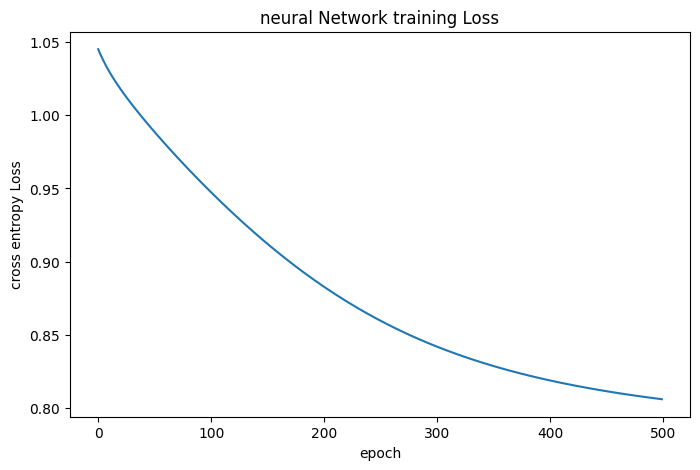

In [198]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(network.loss_history)
plt.title("neural Network training Loss")
plt.xlabel("epoch")
plt.ylabel("cross entropy Loss")
plt.savefig("../results/nn_loss.png", dpi=300)

plt.show()

In [193]:
cm_nn=confusion_matrix(
    y_test,
    predictions,
    n_classes=3)
print(cm_nn)

[[1460  525  446]
 [ 227 5682  810]
 [ 539 3071 1037]]


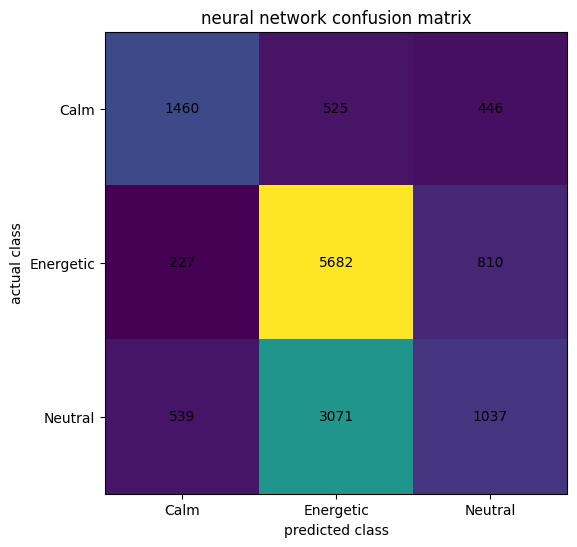

In [196]:
plt.figure(figsize=(6,6))
plt.imshow(cm_nn)
plt.title("neural network confusion matrix")
plt.xlabel("predicted class")
plt.ylabel("actual class")
plt.xticks([0,1,2], class_names)
plt.yticks([0,1,2], class_names)
for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm_nn[i, j],
            ha="center",
            va="center"
        )

plt.savefig("../results/nn_confusion_matrix.png", dpi=300)
plt.show()

In [174]:
precision_values = precision(cm_nn)
recall_values = recall(cm_nn)
f1_values = f1_score(
    precision_values,
    recall_values
)
for i in range(3):
    print(f"\n{class_names[i]}")
    print(f"Precision: {precision_values[i]:.3f}")
    print(f"Recall: {recall_values[i]:.3f}")
    print(f"F1 Score: {f1_values[i]:.3f}")


Calm
Precision: 0.656
Recall: 0.601
F1 Score: 0.627

Energetic
Precision: 0.612
Recall: 0.846
F1 Score: 0.710

Neutral
Precision: 0.452
Recall: 0.223
F1 Score: 0.299


In [179]:
nn_accuracy = network.score(X_test, y_test)
print(f"neural network Accuracy: {nn_accuracy:.4f}")
perceptron_accuracy = perceptron.score(X_test, y_test)
print(f"perceptron Accuracy: {perceptron_accuracy:.4f}")

neural network Accuracy: 0.5928
perceptron Accuracy: 0.4896
